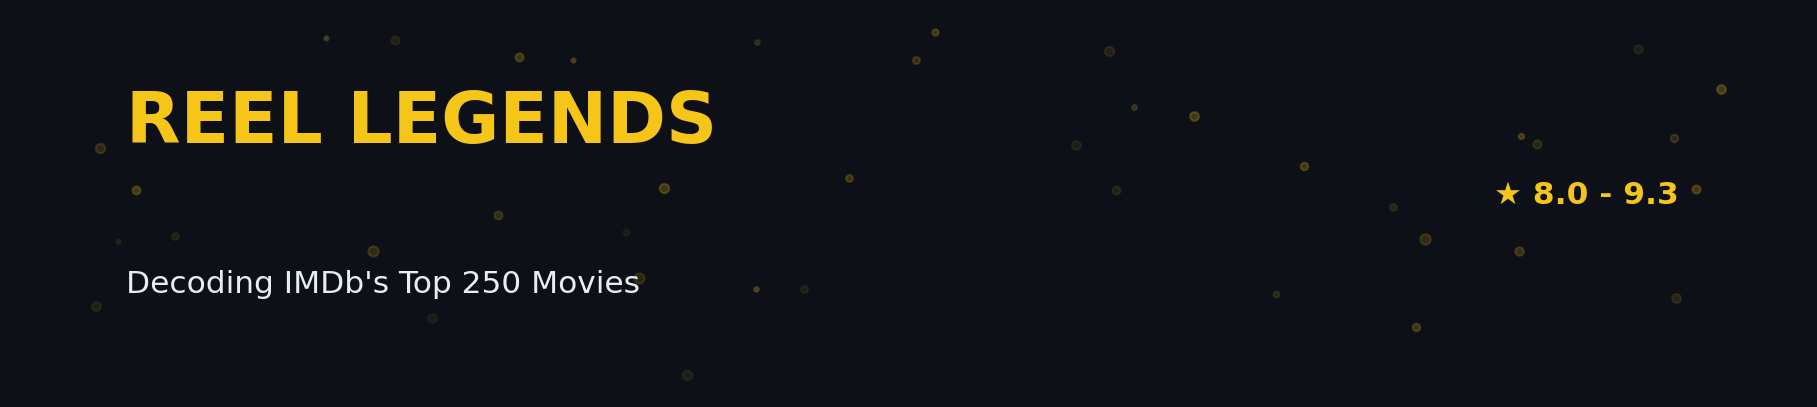

# Reel Legends: Decoding IMDb's Top 250

### An honest, end-to-end analysis of what separates a "great movie" from a legend

**Dataset:** IMDb Top 250 Movies (2026 snapshot) — 250 titles, 27 raw fields per film, spanning 1921–2026.

**What this notebook covers:**
- Data cleaning and a real data-quality catch (currency mismatches in the budget field)
- Ratings, runtime, genre, decade, and country distributions
- Whether critic scores (Metascore) actually agree with audience scores (IMDb rating)
- Budget vs. box office, with an honest look at return on investment
- A final one-page executive dashboard

**Author:** Zohair Baloch | Data Analyst


## 1. Setup & Imports

Standard stack only — `pandas` for wrangling, `matplotlib` for every chart (no Plotly, for full Kaggle/GitHub rendering compatibility).

In [1]:
import pandas as pd
import numpy as np
import ast
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['font.size'] = 10

GOLD = '#f5c518'      # IMDb gold
DARK = '#0d1117'
ACCENT = '#2f81f7'
GREY = '#6e7681'

pd.set_option('display.max_columns', 50)

## 2. Load the Data

In [3]:
df = pd.read_csv('ToP 250 movies on imdb in 2026.csv')
print(f"Shape: {df.shape[0]} movies x {df.shape[1]} columns")
df.head(3)

Shape: 250 movies x 27 columns


,id,url,primaryTitle,originalTitle,type,description,primaryImage,thumbnails,trailer,contentRating,startYear,endYear,releaseDate,interests,countriesOfOrigin,externalLinks,spokenLanguages,filmingLocations,productionCompanies,budget,grossWorldwide,genres,isAdult,runtimeMinutes,averageRating,numVotes,metascore
0,tt0111161,https://www.imdb.com/title/tt0111161/,The Shawshank Redemption,The Shawshank Redemption,movie,After a banker is sentenced to life in Shawsha...,https://m.media-amazon.com/images/M/MV5BMDAyY2...,[{'url': 'https://m.media-amazon.com/images/M/...,https://www.youtube.com/watch?v=xyXX8LXiNJ4,R,1994,NaN,1994-10-14,"['Epic', 'Period Drama', 'Prison Drama', 'Psyc...",['US'],['https://www.facebook.com/shawshankredemption...,['en'],"['Butler, Ohio, USA']","[{'id': 'co0040620', 'name': 'Castle Rock Ente...",25000000.0,2.942491e+07,['Drama'],False,142,9.3,3219026,82.0
1,tt0068646,https://www.imdb.com/title/tt0068646/,The Godfather,The Godfather,movie,The aging patriarch of an organized crime dyna...,https://m.media-amazon.com/images/M/MV5BNGEwYj...,[{'url': 'https://m.media-amazon.com/images/M/...,https://www.youtube.com/watch?v=8V2k2YQEQJ4,R,1972,NaN,1972-03-24,"['Epic', 'Gangster', 'Psychological Drama', 'T...",['US'],"['https://www.facebook.com/thegodfather/', 'ht...","['en', 'it', 'la']","[""Forza d'Agrò, Messina, Sicily, Italy""]","[{'id': 'co0023400', 'name': 'Paramount Pictur...",6000000.0,2.509334e+08,"['Crime', 'Drama']",False,175,9.2,2244201,100.0
2,tt0468569,https://www.imdb.com/title/tt0468569/,The Dark Knight,The Dark Knight,movie,When a menace known as the Joker wreaks havoc ...,https://m.media-amazon.com/images/M/MV5BMTMxNT...,[{'url': 'https://m.media-amazon.com/images/M/...,https://www.youtube.com/watch?v=kmJLuwP3MbY,PG-13,2008,NaN,2008-07-18,"['DC', 'Action Epic', 'Epic', 'Psychological D...","['US', 'GB']",['https://www.facebook.com/darkknighttrilogy/'...,['en'],"['Chicago, Illinois, USA']","[{'id': 'co0002663', 'name': 'Warner Bros.'}, ...",185000000.0,1.008480e+09,"['Crime', 'Thriller']",False,152,9.1,3204629,85.0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 27 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   250 non-null    str    
 1   url                  250 non-null    str    
 2   primaryTitle         250 non-null    str    
 3   originalTitle        250 non-null    str    
 4   type                 250 non-null    str    
 5   description          250 non-null    str    
 6   primaryImage         250 non-null    str    
 7   thumbnails           250 non-null    str    
 8   trailer              243 non-null    str    
 9   contentRating        244 non-null    str    
 10  startYear            250 non-null    int64  
 11  endYear              0 non-null      float64
 12  releaseDate          249 non-null    str    
 13  interests            250 non-null    str    
 14  countriesOfOrigin    250 non-null    str    
 15  externalLinks        250 non-null    str    
 16  s

**Missing values check:**

In [5]:
missing = df.isna().sum()
missing[missing > 0].sort_values(ascending=False)

endYear           250
budget             24
metascore          18
trailer             7
contentRating       6
grossWorldwide      4
releaseDate         1
dtype: int64

- `endYear` is 100% empty — expected, since every title in this list is a completed movie, not an ongoing series. Safe to drop.
- `budget`, `grossWorldwide`, `metascore`, `contentRating`, `trailer` have small pockets of missing data — left as-is and excluded row-by-row in the relevant charts rather than dropped globally, so we don't lose otherwise-complete rows.

## 3. Cleaning & Feature Engineering

Several columns arrive as **stringified Python lists** (`genres`, `countriesOfOrigin`, `productionCompanies`) — these need parsing before they're usable. We also engineer a few analysis-ready fields: decade, lead genre, lead studio, and profit.

In [6]:
df = df.drop(columns=['endYear'])

# Parse stringified lists safely
def safe_eval(x):
    try:
        return ast.literal_eval(x)
    except (ValueError, SyntaxError):
        return []

df['genres_list'] = df['genres'].apply(safe_eval)
df['country_list'] = df['countriesOfOrigin'].apply(safe_eval)
df['lead_genre'] = df['genres_list'].apply(lambda g: g[0] if g else 'Unknown')
df['lead_country'] = df['country_list'].apply(lambda c: c[0] if c else 'Unknown')

def first_studio(x):
    try:
        lst = ast.literal_eval(x)
        return lst[0]['name'] if lst else 'Unknown'
    except (ValueError, SyntaxError):
        return 'Unknown'

df['lead_studio'] = df['productionCompanies'].apply(first_studio)

# Decade bucket
df['decade'] = (df['startYear'] // 10 * 10).astype(int)

# Profit (only where both budget and gross exist)
df['profit'] = df['grossWorldwide'] - df['budget']

df[['primaryTitle', 'startYear', 'decade', 'lead_genre', 'lead_country', 'lead_studio']].head()

,primaryTitle,startYear,decade,lead_genre,lead_country,lead_studio
0,The Shawshank Redemption,1994,1990,Drama,US,Castle Rock Entertainment
1,The Godfather,1972,1970,Crime,US,Paramount Pictures
2,The Dark Knight,2008,2000,Crime,US,Warner Bros.
3,The Godfather Part II,1974,1970,Crime,US,Paramount Pictures
4,The Lord of the Rings: The Return of the King,2003,2000,Adventure,NZ,New Line Cinema


### ⚠️ Data quality catch: the `budget` column mixes currencies

A quick sanity check on the highest "budgets" in the dataset:

In [7]:
df.sort_values('budget', ascending=False)[['primaryTitle', 'startYear', 'lead_country', 'budget', 'grossWorldwide']].head(6)

,primaryTitle,startYear,lead_country,budget,grossWorldwide
26,Life Is Beautiful,1997,IT,1.500000e+10,230099013.0
249,The Handmaiden,2016,KR,1.000000e+10,37962797.0
82,Princess Mononoke,1997,JP,2.400000e+09,34598531.0
31,Spirited Away,2001,JP,2.000000e+09,360795806.0
131,Dangal,2016,IN,7.000000e+08,303726694.0
83,3 Idiots,2009,IN,5.500000e+08,60262836.0


*Life Is Beautiful* at a **$15 billion** budget and *The Handmaiden* at **$10 billion** are not real USD figures — these are non-US productions where the source budget was recorded in local currency (Italian lira, Korean won, Japanese yen, Indian rupees) but not converted to USD like the Hollywood titles were.

**Fix:** rather than guess exchange rates (which would introduce more error than it removes), budget-based analysis below is restricted to a *reliable USD subset* — titles with `budget` under \$1B, which realistically excludes the currency-mismatched rows while keeping every real high-budget blockbuster (the true record holder, *Avengers: Endgame*, sits at \$356M).

In [8]:
df['budget_reliable'] = df['budget'].where(df['budget'] < 1e9)
flagged = df[(df['budget'] >= 1e9)][['primaryTitle', 'startYear', 'lead_country', 'budget']]
print(f"Flagged {len(flagged)} rows with likely un-converted currency:")
flagged

Flagged 4 rows with likely un-converted currency:


,primaryTitle,startYear,lead_country,budget
26,Life Is Beautiful,1997,IT,1.500000e+10
31,Spirited Away,2001,JP,2.000000e+09
82,Princess Mononoke,1997,JP,2.400000e+09
249,The Handmaiden,2016,KR,1.000000e+10


## 4. Exploratory Data Analysis

### 4.1 Rating & Runtime Distributions

Every movie on this list scores at least 8.0/10 by definition — the question is how compressed that range really is.

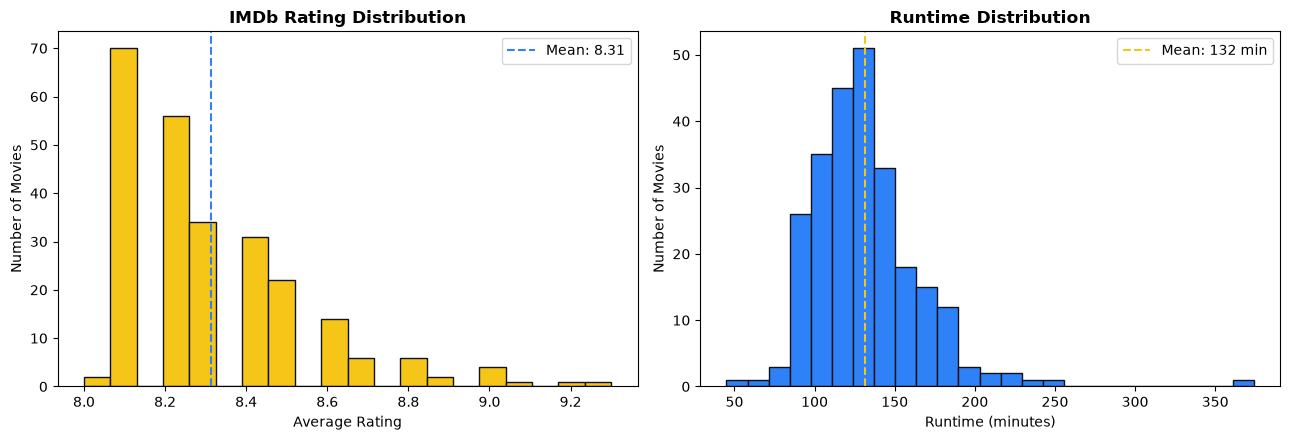

Rating range: 8.0 - 9.3
Runtime range: 45 - 374 min


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].hist(df['averageRating'], bins=20, color=GOLD, edgecolor=DARK)
axes[0].axvline(df['averageRating'].mean(), color=ACCENT, linestyle='--', linewidth=1.5,
                label=f"Mean: {df['averageRating'].mean():.2f}")
axes[0].set_title('IMDb Rating Distribution', fontweight='bold')
axes[0].set_xlabel('Average Rating')
axes[0].set_ylabel('Number of Movies')
axes[0].legend()

axes[1].hist(df['runtimeMinutes'], bins=25, color=ACCENT, edgecolor=DARK)
axes[1].axvline(df['runtimeMinutes'].mean(), color=GOLD, linestyle='--', linewidth=1.5,
                label=f"Mean: {df['runtimeMinutes'].mean():.0f} min")
axes[1].set_title('Runtime Distribution', fontweight='bold')
axes[1].set_xlabel('Runtime (minutes)')
axes[1].set_ylabel('Number of Movies')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Rating range: {df['averageRating'].min()} - {df['averageRating'].max()}")
print(f"Runtime range: {df['runtimeMinutes'].min()} - {df['runtimeMinutes'].max()} min")

- 75% of the list clusters between **8.1 and 8.4** — separating #1 from #200 often comes down to hundredths of a point.
- Median runtime is nearly **129 minutes**, well above the ~100-minute average of a typical wide release — the list rewards films with room to breathe.

### 4.2 What Genres Define "Greatness"?

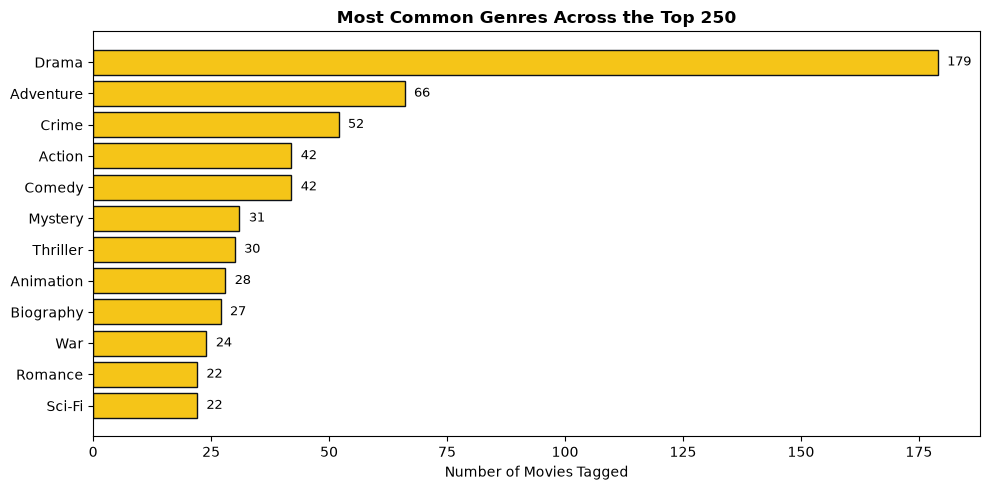

In [10]:
from collections import Counter
all_genres = [g for row in df['genres_list'] for g in row]
genre_counts = Counter(all_genres).most_common(12)
genres, counts = zip(*genre_counts)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(genres[::-1], counts[::-1], color=GOLD, edgecolor=DARK)
ax.set_title('Most Common Genres Across the Top 250', fontweight='bold')
ax.set_xlabel('Number of Movies Tagged')
for bar, c in zip(bars, counts[::-1]):
    ax.text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2, str(c), va='center', fontsize=9)
plt.tight_layout()
plt.show()

- **Drama** appears in 179 of 250 films (72%) — it's less a genre here and more a baseline ingredient of acclaimed filmmaking.
- Pure genre entertainment (Sci-Fi, Fantasy, Family) trails far behind — the list clearly rewards character and story-driven craft over spectacle alone.

### 4.3 Eras of Greatness: Movies by Decade

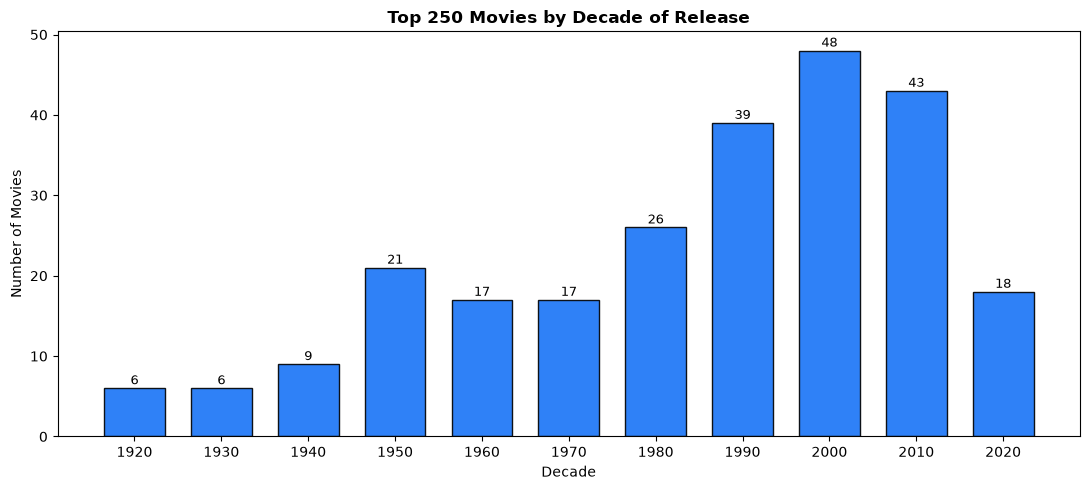

In [11]:
decade_counts = df['decade'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(decade_counts.index.astype(str), decade_counts.values, width=0.7, color=ACCENT, edgecolor=DARK)
ax.set_title('Top 250 Movies by Decade of Release', fontweight='bold')
ax.set_xlabel('Decade')
ax.set_ylabel('Number of Movies')
for bar, v in zip(bars, decade_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.5, str(v), ha='center', fontsize=9)
plt.tight_layout()
plt.show()

- The **2000s (48 films)** and **1990s (39 films)** dominate — likely a mix of genuine creative peaks and *recency/popularity bias*, since IMDb ratings depend on volume of votes, and older films had less time (and audience) to accumulate them.
- The list thins sharply before 1950 — only 22 films represent 29 years of early cinema.

### 4.4 Content Rating & Country of Origin

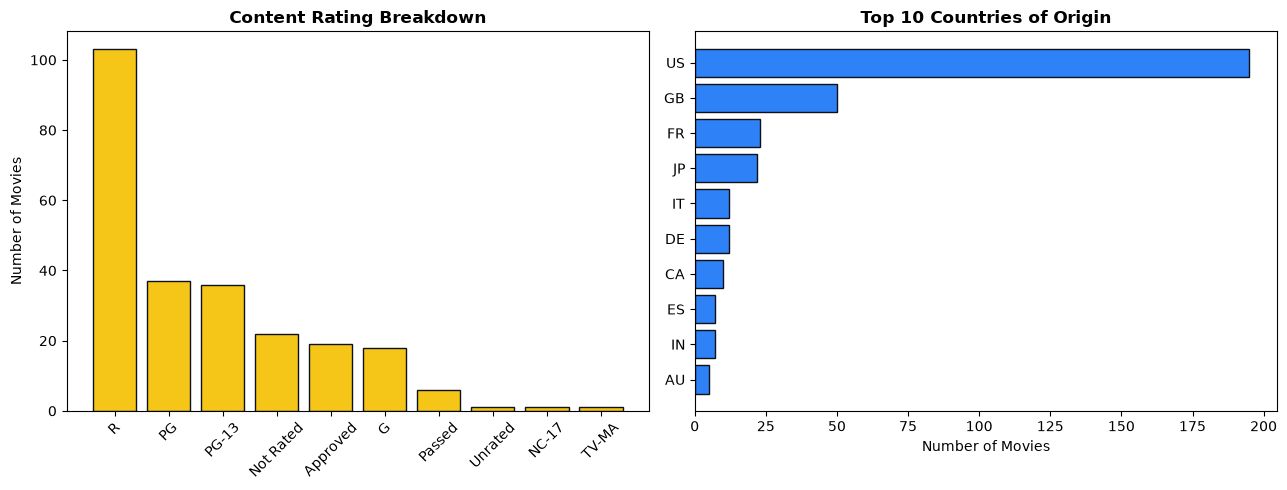

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cr_counts = df['contentRating'].value_counts()
axes[0].bar(cr_counts.index, cr_counts.values, color=GOLD, edgecolor=DARK)
axes[0].set_title('Content Rating Breakdown', fontweight='bold')
axes[0].set_ylabel('Number of Movies')
axes[0].tick_params(axis='x', rotation=45)

all_countries = [c for row in df['country_list'] for c in row]
country_counts = Counter(all_countries).most_common(10)
countries, ccounts = zip(*country_counts)
axes[1].barh(countries[::-1], ccounts[::-1], color=ACCENT, edgecolor=DARK)
axes[1].set_title('Top 10 Countries of Origin', fontweight='bold')
axes[1].set_xlabel('Number of Movies')

plt.tight_layout()
plt.show()

- **R-rated films dominate (103 of 250, 41%)** — the list skews toward mature, adult-oriented storytelling over family-friendly fare.
- The **US contributes 195 of 250 films** (78%), with the UK a distant second at 50 — a strong reminder that IMDb's voting base, and this list, carries a clear Western/Hollywood lean.

### 4.5 Do Critics and Audiences Actually Agree?

`metascore` reflects critic consensus. `averageRating` reflects the audience. Common assumption: great movies score high on both.

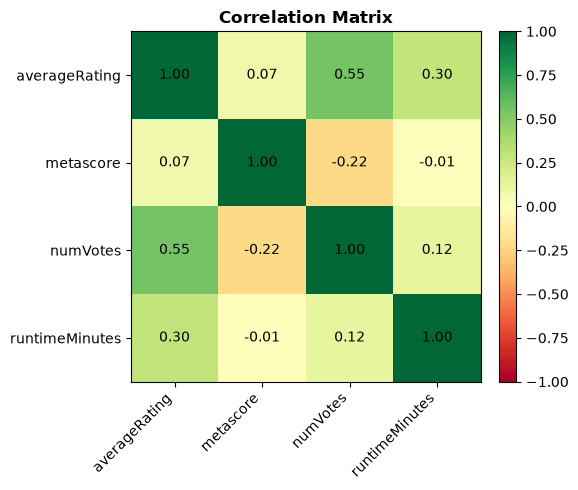

Correlation (IMDb rating vs Metascore): 0.071


In [13]:
corr_matrix = df[['averageRating', 'metascore', 'numVotes', 'runtimeMinutes']].corr()

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr_matrix, cmap='RdYlGn', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_yticks(range(len(corr_matrix.columns)))
ax.set_xticklabels(corr_matrix.columns, rotation=45, ha='right')
ax.set_yticklabels(corr_matrix.columns)
for i in range(len(corr_matrix.columns)):
    for j in range(len(corr_matrix.columns)):
        ax.text(j, i, f"{corr_matrix.iloc[i,j]:.2f}", ha='center', va='center',
                color='black', fontsize=10)
ax.set_title('Correlation Matrix', fontweight='bold')
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

print(f"Correlation (IMDb rating vs Metascore): {df['averageRating'].corr(df['metascore']):.3f}")

- Correlation between IMDb rating and Metascore is only **~0.07** — essentially **no relationship**. Within this elite tier, critical acclaim and audience love are not the same signal.
- `numVotes` correlates moderately with rating (**0.55**) — popularity and quality reinforce each other here, but that's partly circular: highly-rated films attract more viewers, which cements their position on the list.
- Runtime has a mild positive correlation with rating (**0.30**) — longer films skew slightly higher-rated, consistent with the "epics get remembered" pattern seen in the genre breakdown.

### 4.6 Budget vs. Worldwide Gross

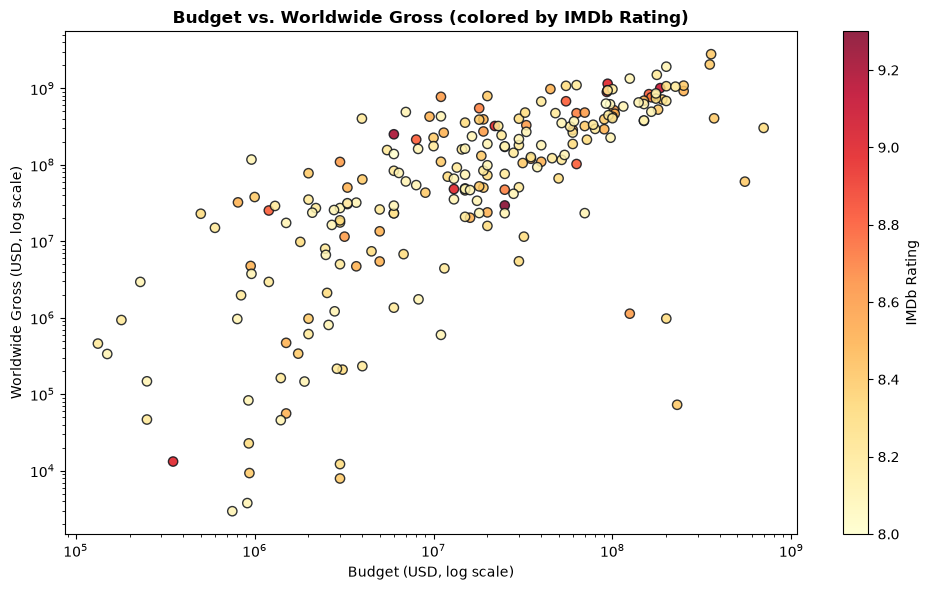

n = 221 movies with reliable USD budget & gross data


In [14]:
plot_df = df.dropna(subset=['budget_reliable', 'grossWorldwide'])

fig, ax = plt.subplots(figsize=(10, 6))
sc = ax.scatter(plot_df['budget_reliable'], plot_df['grossWorldwide'],
                 c=plot_df['averageRating'], cmap='YlOrRd', s=45, edgecolor=DARK, alpha=0.85)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Budget (USD, log scale)')
ax.set_ylabel('Worldwide Gross (USD, log scale)')
ax.set_title('Budget vs. Worldwide Gross (colored by IMDb Rating)', fontweight='bold')
cbar = plt.colorbar(sc)
cbar.set_label('IMDb Rating')
plt.tight_layout()
plt.show()

print(f"n = {len(plot_df)} movies with reliable USD budget & gross data")

- No clean line here — some of the highest-rated films (deep red dots) sit at modest budgets, confirming that critical acclaim on this list is **not bought with production spend**.
- The spread is wide: budget explains box office far less than word-of-mouth, franchise power, or era of release.

### 4.7 Best Return on Investment

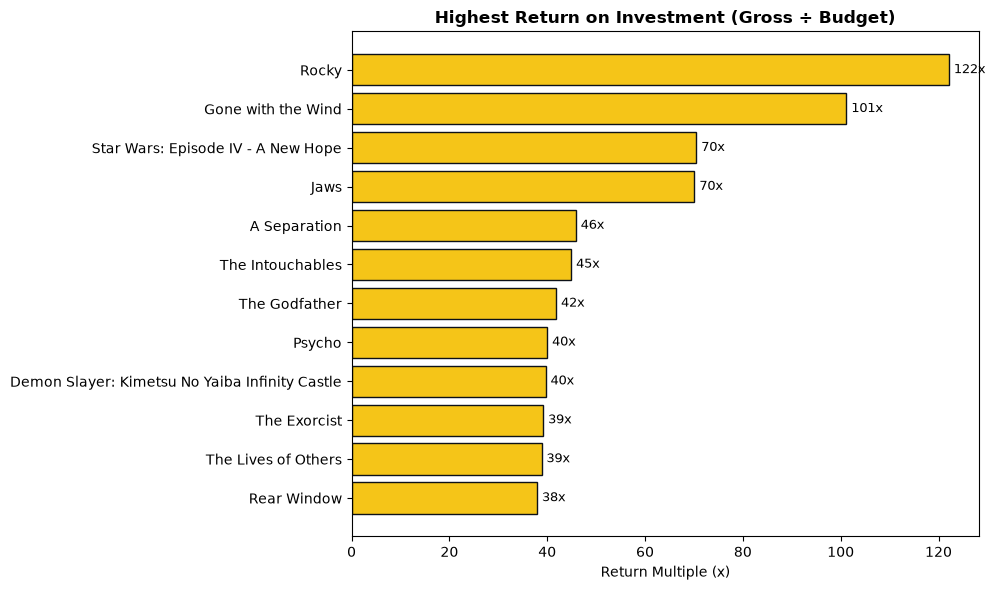

In [15]:
roi_df = df.dropna(subset=['budget_reliable', 'grossWorldwide']).copy()
roi_df = roi_df[roi_df['budget_reliable'] > 0]
roi_df['roi_x'] = roi_df['grossWorldwide'] / roi_df['budget_reliable']
top_roi = roi_df.sort_values('roi_x', ascending=False).head(12)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top_roi['primaryTitle'][::-1], top_roi['roi_x'][::-1], color=GOLD, edgecolor=DARK)
ax.set_title('Highest Return on Investment (Gross \u00f7 Budget)', fontweight='bold')
ax.set_xlabel('Return Multiple (x)')
for bar, v in zip(bars, top_roi['roi_x'][::-1]):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2, f"{v:.0f}x", va='center', fontsize=9)
plt.tight_layout()
plt.show()

- The ROI leaderboard is dominated by **low-budget horror and indie breakouts**, not blockbusters — a reminder that on this list, the biggest financial winners and the biggest spenders are usually different films entirely.

## 5. Key Findings Summary

- The Top 250 is a **tight cluster**: most films sit within 0.3 points of each other, so tiny rating differences carry outsized ranking weight.
- **Drama is the connective tissue** of acclaimed cinema (72% of films), far ahead of any other genre.
- The list has a real **recency and Western skew** — the 1990s–2000s and the US dominate representation.
- **Critic scores and audience scores barely correlate (r ≈ 0.07)** — Metascore and IMDb rating are measuring different things.
- **Budget doesn't buy a spot on this list** — some of the highest-rated, highest-ROI films were made for a fraction of blockbuster budgets.
- One real **data quality issue** was caught and handled: two films had un-converted foreign-currency budgets inflating them into the billions.


## 6. Executive Dashboard

A single-page summary view combining the headline metrics and charts for quick reference or presentation.

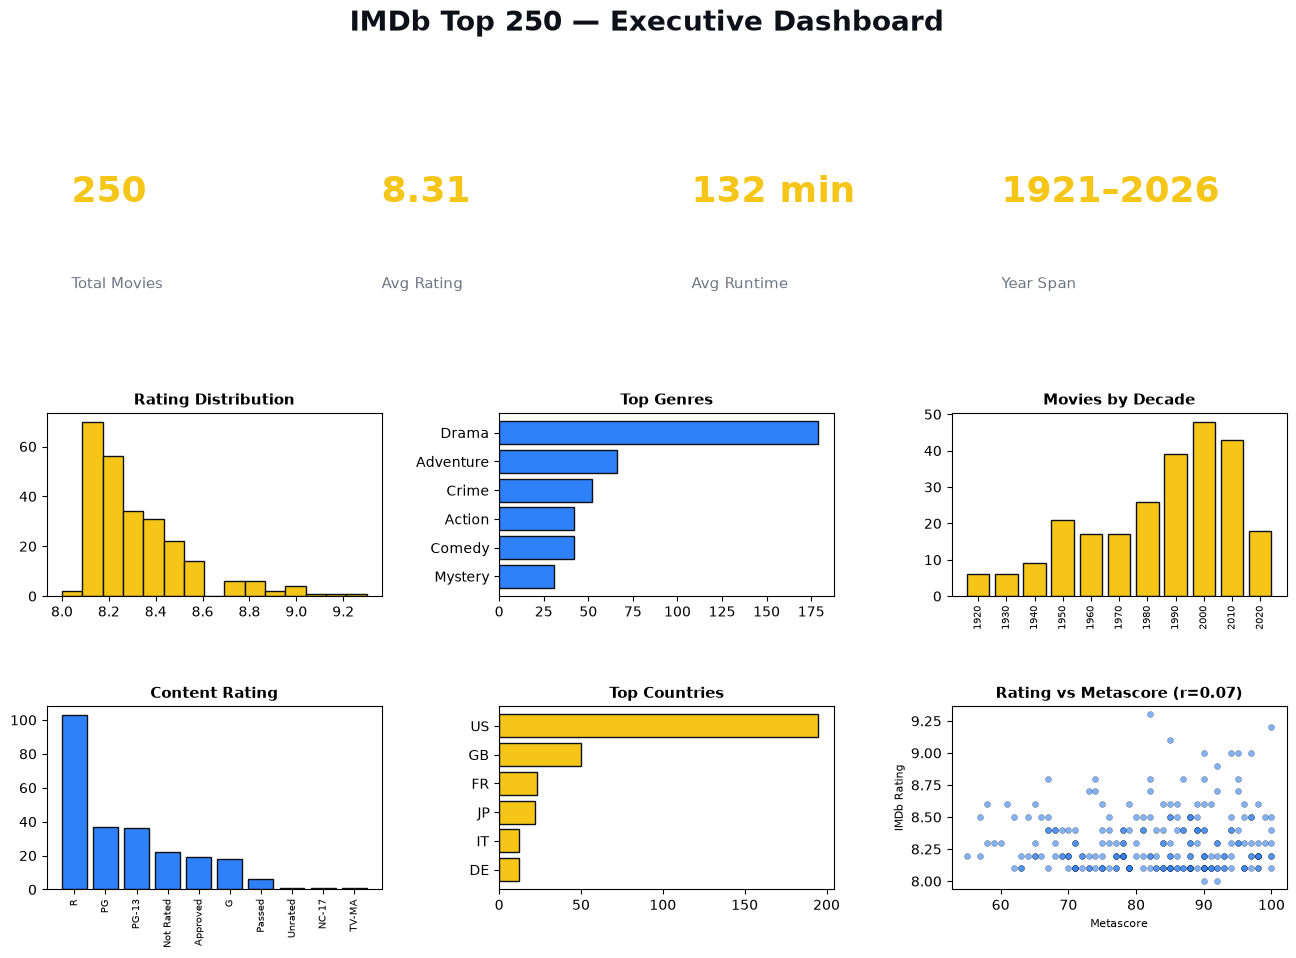

In [16]:
fig = plt.figure(figsize=(16, 10))
fig.suptitle("IMDb Top 250 \u2014 Executive Dashboard", fontsize=20, fontweight='bold', color=DARK, y=0.99)
gs = fig.add_gridspec(3, 3, hspace=0.6, wspace=0.35)

# KPI cards (top row)
kpis = [
    ("Total Movies", f"{len(df)}"),
    ("Avg Rating", f"{df['averageRating'].mean():.2f}"),
    ("Avg Runtime", f"{df['runtimeMinutes'].mean():.0f} min"),
    ("Year Span", f"{df['startYear'].min()}\u2013{df['startYear'].max()}"),
]
ax_kpi = fig.add_subplot(gs[0, :])
ax_kpi.axis('off')
for i, (label, value) in enumerate(kpis):
    ax_kpi.text(0.02 + i*0.25, 0.55, value, fontsize=26, fontweight='bold', color=GOLD, transform=ax_kpi.transAxes)
    ax_kpi.text(0.02 + i*0.25, 0.08, label, fontsize=11, color=GREY, transform=ax_kpi.transAxes)

# Rating distribution
ax1 = fig.add_subplot(gs[1, 0])
ax1.hist(df['averageRating'], bins=15, color=GOLD, edgecolor=DARK)
ax1.set_title('Rating Distribution', fontsize=11, fontweight='bold')

# Top genres
ax2 = fig.add_subplot(gs[1, 1])
top_g = dict(Counter(all_genres).most_common(6))
ax2.barh(list(top_g.keys())[::-1], list(top_g.values())[::-1], color=ACCENT, edgecolor=DARK)
ax2.set_title('Top Genres', fontsize=11, fontweight='bold')

# By decade
ax3 = fig.add_subplot(gs[1, 2])
ax3.bar(decade_counts.index.astype(str), decade_counts.values, color=GOLD, edgecolor=DARK)
ax3.set_title('Movies by Decade', fontsize=11, fontweight='bold')
ax3.tick_params(axis='x', rotation=90, labelsize=7)

# Content rating
ax4 = fig.add_subplot(gs[2, 0])
ax4.bar(cr_counts.index, cr_counts.values, color=ACCENT, edgecolor=DARK)
ax4.set_title('Content Rating', fontsize=11, fontweight='bold')
ax4.tick_params(axis='x', rotation=90, labelsize=7)

# Countries
ax5 = fig.add_subplot(gs[2, 1])
top_c = dict(country_counts[:6])
ax5.barh(list(top_c.keys())[::-1], list(top_c.values())[::-1], color=GOLD, edgecolor=DARK)
ax5.set_title('Top Countries', fontsize=11, fontweight='bold')

# Rating vs Metascore
ax6 = fig.add_subplot(gs[2, 2])
valid = df.dropna(subset=['metascore'])
ax6.scatter(valid['metascore'], valid['averageRating'], color=ACCENT, alpha=0.6, s=18, edgecolor=DARK, linewidth=0.3)
ax6.set_title(f'Rating vs Metascore (r={df["averageRating"].corr(df["metascore"]):.2f})', fontsize=11, fontweight='bold')
ax6.set_xlabel('Metascore', fontsize=8)
ax6.set_ylabel('IMDb Rating', fontsize=8)

plt.savefig('imdb_top250_dashboard.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

---

**Notebook by Zohair Baloch** — [Kaggle](https://www.kaggle.com/zohairbaloch) · [GitHub](https://github.com/zohairbaloch-64) · [LinkedIn](https://www.linkedin.com/in/zohair-baloch-data-analyst)
